# Baseline 3 – Truy xuất bằng TF-IDF trên Tiêu đề

**Mục tiêu:** Vector hóa cột `title` bằng `TfidfVectorizer`, tính **Cosine Similarity**, đánh giá trên **toàn bộ 34,250 dòng** của train.csv.


## 1. Import thư viện


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

DATA_DIR  = r'E:\study\DoAnPython\code\DoAnPython\project\data\raw'
CSV_PATH  = os.path.join(DATA_DIR, 'train.csv')
PROCESSED = '../data/processed/'
RESULTS   = '../results/'
os.makedirs(RESULTS, exist_ok=True)

print('Import thư viện thành công!')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print(f'PyTorch version : {torch.__version__}')
# Kiểm tra máy có GPU không. GPU giúp chạy nhanh hơn CPU rất nhiều.
# Laptop bình thường thường sẽ hiện 'cpu' – không sao, vẫn chạy được.
print(f'Device: {"cuda" if torch.cuda.is_available() else "cpu"}')



Import thư viện thành công!
PyTorch version : 2.12.0+cu126
Device: cuda


**Nhận xét:** Baseline văn bản — bỏ qua pixel, chỉ dựa tên sản phẩm.


## 2. Đọc toàn bộ dữ liệu train.csv (34,250 dòng)

- Đọc **toàn bộ** `train.csv` — tuyệt đối không dùng `.head()` hay cắt nhỏ dữ liệu.
- Mỗi query đều có đáp án trong gallery để đảm bảo giao thức đánh giá chính xác.


In [2]:
# Đọc TOÀN BỘ train.csv
df = pd.read_csv(CSV_PATH)
print(f'Tổng số dòng: {len(df):,}')
print(f'Số nhóm (label_group): {df["label_group"].nunique():,}')
print(df.head(3))


Tổng số dòng: 34,250
Số nhóm (label_group): 11,014
         posting_id                                 image       image_phash  \
0   train_129225211  0000a68812bc7e98c42888dfb1c07da0.jpg  94974f937d4c2433   
1  train_3386243561  00039780dfc94d01db8676fe789ecd05.jpg  af3f9460c2838f0f   
2  train_2288590299  000a190fdd715a2a36faed16e2c65df7.jpg  b94cb00ed3e50f78   

                                               title  label_group  
0                          Paper Bag Victoria Secret    249114794  
1  Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DO...   2937985045  
2        Maling TTS Canned Pork Luncheon Meat 397 gr   2395904891  


**Nhận xét:** Dùng toàn bộ dataset để đảm bảo mỗi query đều có ít nhất một ảnh cùng nhóm trong gallery.


## 3. TF-IDF Vector hóa tiêu đề

- `TfidfVectorizer`: unigram + bigram, tối đa 10,000 feature.
- Ma trận TF-IDF dạng sparse → tiết kiệm RAM.


In [3]:
titles = df['title'].fillna('').astype(str)
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=1)
tfidf_matrix = vectorizer.fit_transform(titles)  # sparse matrix (n, max_features)

print(f'Số ảnh: {tfidf_matrix.shape[0]:,}')
print(f'Số chiều TF-IDF: {tfidf_matrix.shape[1]:,}')
print(f'Dạng lưu trữ: {type(tfidf_matrix).__name__}  (sparse – tiết kiệm RAM)')


Số ảnh: 34,250
Số chiều TF-IDF: 10,000
Dạng lưu trữ: csr_matrix  (sparse – tiết kiệm RAM)


**Nhận xét:** Ma trận sparse – không cần lưu toàn bộ cosine matrix 34K×34K vào RAM.


## 4. Demo Top-5 truy xuất theo tiêu đề

Minh họa một query: tính cosine similarity hàng đơn với toàn bộ gallery, **loại self**.


In [4]:
query_idx = 0
# Tính cosine similarity 1 hàng với toàn bộ
sim_row = cosine_similarity(tfidf_matrix[query_idx], tfidf_matrix).flatten().astype(np.float32)
sim_row[query_idx] = -1.0  # loại chính query

top5_idx = np.argsort(-sim_row)[:5]
q_group = df['label_group'].iloc[query_idx]

print(f'Tiêu đề query: {titles.iloc[query_idx][:100]}')
print(f'Nhóm: {q_group}\n')
for rank, j in enumerate(top5_idx, 1):
    dung = df['label_group'].iloc[j] == q_group
    print(
        f'  {rank}. score={sim_row[j]:.4f}  '
        f'{"✓" if dung else "✗"}  {titles.iloc[j][:70]}...'
    )


Tiêu đề query: Paper Bag Victoria Secret
Nhóm: 249114794

  1. score=1.0000  ✓  PAPER BAG VICTORIA SECRET...
  2. score=0.5276  ✗  Dengan Paper Bag TABITA EXCLUSIVE ORIGINAL KEMASAN KECIL...
  3. score=0.5244  ✗  PAPER BAG THE BODY SHOP...
  4. score=0.5203  ✗  Paper Bag Tas Kertas Polos Ukuran 18x5x22...
  5. score=0.4910  ✗  Paper Bag The Body Shop Small...


## 5. Precision@K, Recall@K và mAP

- **BẮT BUỘC** loại chính query khỏi kết quả Top-K trước khi tính.
- Tính từng hàng (row-by-row) để tránh OOM khi full matrix 34K×34K.


In [5]:
K_LIST = [1, 3, 5, 10]
MAX_K  = max(K_LIST)
labels = df['label_group'].values
n = len(labels)

# Tính số lượng ảnh cùng nhóm cho mỗi posting (trừ chính nó)
from collections import Counter
label_counts = Counter(labels)

def average_precision(ranked_labels, true_label, total_relevant):
    if total_relevant == 0:
        return 0.0
    ap, hits = 0.0, 0
    for rank, label in enumerate(ranked_labels, 1):
        if label == true_label:
            hits += 1
            ap += hits / rank
    return ap / total_relevant

rows, all_ap = [], []
PRINT_STEP = 2000

for i in range(n):
    true_label = labels[i]
    total_relevant = label_counts[true_label] - 1  # trừ chính nó
    if total_relevant == 0:
        continue

    # Tính cosine similarity hàng i với toàn bộ (sparse × sparse.T)
    sim_row = cosine_similarity(tfidf_matrix[i], tfidf_matrix).flatten().astype(np.float32)
    sim_row[i] = -1.0  # BẮT BUỘC loại chính query

    top_idx = np.argsort(-sim_row)[:MAX_K]
    ranked_labels = [labels[j] for j in top_idx]

    ap = average_precision(ranked_labels, true_label, total_relevant)
    all_ap.append(ap)

    row = {'posting_id': df['posting_id'].iloc[i], 'label_group': true_label}
    for k in K_LIST:
        top_k_labels = ranked_labels[:k]
        hits = sum(1 for lbl in top_k_labels if lbl == true_label)
        row[f'Precision@{k}'] = round(hits / k, 4)
        denom = min(total_relevant, k) if total_relevant > 0 else 1
        row[f'Recall@{k}'] = round(hits / denom, 4)
    rows.append(row)

    if (i + 1) % PRINT_STEP == 0:
        print(f'  Đã xử lý {i+1:,}/{n:,} ...')

detail_df = pd.DataFrame(rows)
detail_df['AP'] = [round(v, 4) for v in all_ap]

summary = []
for k in K_LIST:
    summary.append({
        'K': k,
        'Precision@K': round(detail_df[f'Precision@{k}'].mean(), 4),
        'Recall@K': round(detail_df[f'Recall@{k}'].mean(), 4),
    })
metrics_df = pd.DataFrame(summary)
mAP = round(float(np.mean(all_ap)), 4)

print(f'\nMETRIC TRUNG BÌNH TRÊN TOÀN BỘ {n:,} ẢNH')
print(metrics_df.to_string(index=False))
print(f'\nmAP (mean Average Precision) = {mAP:.4f}')
metrics_df['mAP'] = mAP

metrics_df.to_csv(os.path.join(RESULTS, 'avg_metrics_tfidf.csv'), index=False)
detail_df.to_csv(os.path.join(RESULTS, 'detail_metrics_tfidf.csv'), index=False)
print(f'Đã lưu CSV vào {RESULTS}')


  Đã xử lý 2,000/34,250 ...
  Đã xử lý 4,000/34,250 ...
  Đã xử lý 6,000/34,250 ...
  Đã xử lý 8,000/34,250 ...
  Đã xử lý 10,000/34,250 ...
  Đã xử lý 12,000/34,250 ...
  Đã xử lý 14,000/34,250 ...
  Đã xử lý 16,000/34,250 ...
  Đã xử lý 18,000/34,250 ...
  Đã xử lý 20,000/34,250 ...
  Đã xử lý 22,000/34,250 ...
  Đã xử lý 24,000/34,250 ...
  Đã xử lý 26,000/34,250 ...
  Đã xử lý 28,000/34,250 ...
  Đã xử lý 30,000/34,250 ...
  Đã xử lý 32,000/34,250 ...
  Đã xử lý 34,000/34,250 ...

METRIC TRUNG BÌNH TRÊN TOÀN BỘ 34,250 ẢNH
 K  Precision@K  Recall@K
 1       0.5922    0.5922
 3       0.4108    0.6001
 5       0.3313    0.6349
10       0.2336    0.7034

mAP (mean Average Precision) = 0.5204
Đã lưu CSV vào ../results/


**Nhận xét:** Metric cho biết tiêu đề có đủ phân biệt các nhóm sản phẩm hay không.


## 6. Biểu đồ metric


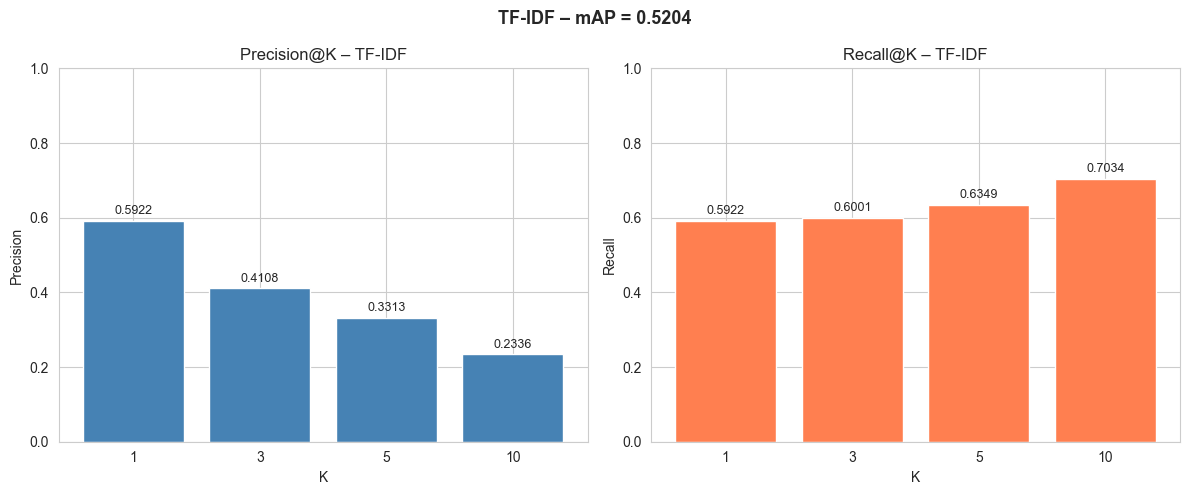

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(metrics_df['K'].astype(str), metrics_df['Precision@K'], color='steelblue')
axes[0].set_title('Precision@K – TF-IDF')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Precision')
axes[0].set_ylim(0, 1)
for bar, val in zip(axes[0].patches, metrics_df['Precision@K']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9)

axes[1].bar(metrics_df['K'].astype(str), metrics_df['Recall@K'], color='coral')
axes[1].set_title('Recall@K – TF-IDF')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Recall')
axes[1].set_ylim(0, 1)
for bar, val in zip(axes[1].patches, metrics_df['Recall@K']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9)

fig.suptitle(f'TF-IDF – mAP = {mAP:.4f}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'metrics_tfidf.png'), dpi=150)
plt.show()


## 7. Xuất kết quả dự đoán Top-5

- Xuất file `ket_qua_tfidf.csv` gồm 2 cột: `posting_id` và `preds_tfidf` (list Top-5 posting_id được dự đoán).
- **BẮT BUỘC** loại chính query khỏi danh sách kết quả trước khi lấy Top-5.


In [7]:
TOP_K_EXPORT = 5
posting_ids = df['posting_id'].values

result_rows = []
PRINT_STEP = 2000

for i in range(n):
    # Tính cosine similarity hàng i với toàn bộ
    sim_row = cosine_similarity(tfidf_matrix[i], tfidf_matrix).flatten().astype(np.float32)
    sim_row[i] = -1.0  # BẮT BUỘC loại chính query

    top5_idx = np.argsort(-sim_row)[:TOP_K_EXPORT]
    preds = [posting_ids[j] for j in top5_idx]
    result_rows.append({
        'posting_id': posting_ids[i],
        'preds_tfidf': ' '.join(preds)
    })

    if (i + 1) % PRINT_STEP == 0:
        print(f'  Đã xử lý {i+1:,}/{n:,} ...')

result_df = pd.DataFrame(result_rows)

output_path = os.path.join(RESULTS, 'ket_qua_tfidf.csv')
result_df.to_csv(output_path, index=False)
print(f'\nĐã xuất kết quả: {output_path}')
print(f'Số dòng: {len(result_df):,}')
print('Mẫu 5 dòng đầu:')
print(result_df.head())


  Đã xử lý 2,000/34,250 ...
  Đã xử lý 4,000/34,250 ...
  Đã xử lý 6,000/34,250 ...
  Đã xử lý 8,000/34,250 ...
  Đã xử lý 10,000/34,250 ...
  Đã xử lý 12,000/34,250 ...
  Đã xử lý 14,000/34,250 ...
  Đã xử lý 16,000/34,250 ...
  Đã xử lý 18,000/34,250 ...
  Đã xử lý 20,000/34,250 ...
  Đã xử lý 22,000/34,250 ...
  Đã xử lý 24,000/34,250 ...
  Đã xử lý 26,000/34,250 ...
  Đã xử lý 28,000/34,250 ...
  Đã xử lý 30,000/34,250 ...
  Đã xử lý 32,000/34,250 ...
  Đã xử lý 34,000/34,250 ...

Đã xuất kết quả: ../results/ket_qua_tfidf.csv
Số dòng: 34,250
Mẫu 5 dòng đầu:
         posting_id                                        preds_tfidf
0   train_129225211  train_2278313361 train_455286484 train_3982974...
1  train_3386243561  train_1974987067 train_211200223 train_8600273...
2  train_2288590299  train_3803689425 train_3877758861 train_242628...
3  train_2406599165  train_3576714541 train_1744956981 train_352677...
4  train_3369186413  train_921438619 train_2743870047 train_2772640...
